# **1. Dataset Preparation and Preprocessing**

Training set: (13600, 28, 28, 1), Labels: (13600, 10)
Testing set: (3000, 28, 28, 1), Labels: (3000, 10)


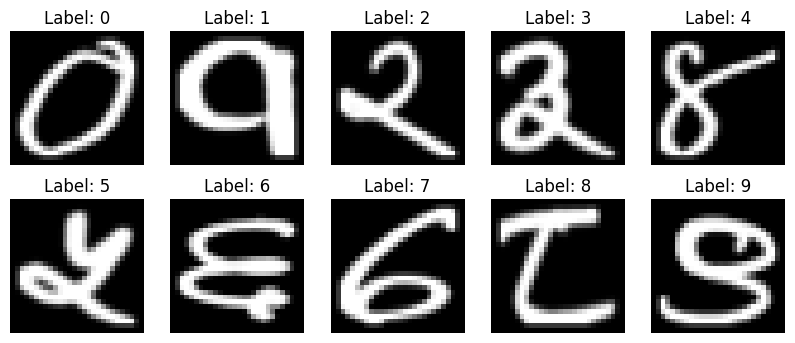

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from PIL import Image # Import Pillow

# Define dataset paths
train_dir = "/content/drive/MyDrive/SEM6_AI/Week7/Copy of devnagari digit/DevanagariHandwrittenDigitDataset/Train"
test_dir = "/content/drive/MyDrive/SEM6_AI/Week7/Copy of devnagari digit/DevanagariHandwrittenDigitDataset/Test"

# Define image size
img_height, img_width = 28, 28

# Function to load images and labels using PIL
def load_images_from_folder(folder):
  images = []
  labels = []
  class_names = sorted(os.listdir(folder)) # Sorted class names (digit_0, digit_1, ...)
  class_map = {name: i for i, name in enumerate(class_names)} # Map class names to labels
  for class_name in class_names:
    class_path = os.path.join(folder, class_name) # Builds the full path to the class sub-folder, e.g. "dataset/Train/digit_0".
    label = class_map[class_name]
    for filename in os.listdir(class_path):
      img_path = os.path.join(class_path, filename)
      # Load image using PIL
      img = Image.open(img_path).convert("L") # Convert to grayscale
      img = img.resize((img_width, img_height)) # Resize to (28,28)
      img = np.array(img) / 255.0 # Normalize pixel values to [0,1]
      images.append(img)
      labels.append(label)
  return np.array(images), np.array(labels)

# Load training and testing datasets
x_train, y_train = load_images_from_folder(train_dir)
x_test, y_test = load_images_from_folder(test_dir)

# Reshape images for Keras input
x_train = x_train.reshape(-1, img_height, img_width, 1) # Shape (num_samples, 28, 28, 1)
x_test = x_test.reshape(-1, img_height, img_width, 1)

# Shuffle the images
indices = np.random.permutation(len(x_train))
x_train = x_train[indices]
y_train = y_train[indices]

# Split BEFORE one-hot encoding
x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

# One-hot encode labels
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

# Print dataset shape
print(f"Training set: {x_train.shape}, Labels: {y_train.shape}")
print(f"Testing set: {x_test.shape}, Labels: {y_test.shape}")

# Visualize some images
plt.figure(figsize=(10, 4))
for digit in range(10):
    # Find first image with this label
    idx = np.argmax(y_train[:, digit] == 1)
    plt.subplot(2, 5, digit + 1)
    plt.imshow(x_train[idx].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {digit}")
    plt.axis("off")
plt.show()





**Adding noise to the images for denoising purposes (Gaussian noise)**

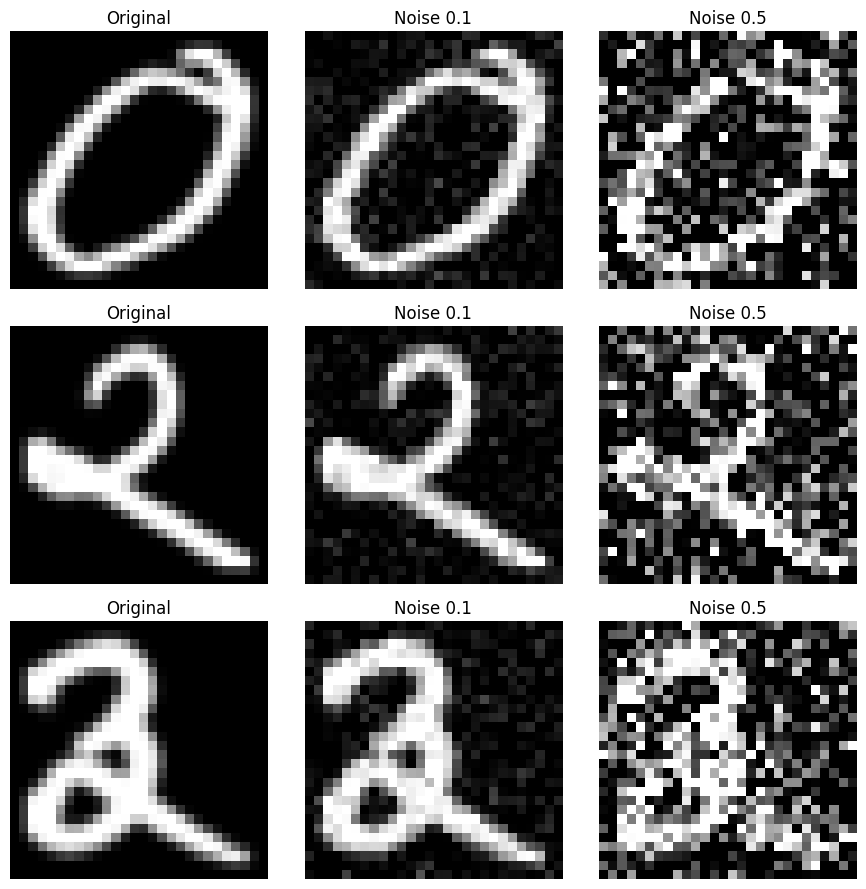

In [ ]:

#Generate noisy versions
noise_factor_low = 0.1
noise_factor_high = 0.5

x_train_noisy_low = x_train + noise_factor_low * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_train_noisy_high = x_train + noise_factor_high * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)

x_test_noisy_low = x_test + noise_factor_low * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)
x_test_noisy_high = x_test + noise_factor_high * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

x_val_noisy_low = x_val + noise_factor_low * np.random.normal(loc=0.0, scale=1.0, size=x_val.shape)
x_val_noisy_high = x_val + noise_factor_high * np.random.normal(loc=0.0, scale=1.0, size=x_val.shape)

# Clip pixel values to [0, 1]
x_train_noisy_low = np.clip(x_train_noisy_low, 0., 1.)
x_test_noisy_low = np.clip(x_test_noisy_low, 0., 1.)

x_train_noisy_high = np.clip(x_train_noisy_high, 0., 1.)
x_test_noisy_high = np.clip(x_test_noisy_high, 0., 1.)

x_val_noisy_low = np.clip(x_val_noisy_low, 0., 1.)
x_val_noisy_high = np.clip(x_val_noisy_high, 0., 1.)

#Visualize in a 3 x 3 grid
n = 3 # number of images to show
plt.figure(figsize=(9, 9))
for i in range(n):

  # Original image
  ax = plt.subplot(n, 3, i * 3 + 1)
  plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
  plt.title("Original")
  plt.axis('off')

  # Low noise image
  ax = plt.subplot(n, 3, i * 3 + 2)
  plt.imshow(x_train_noisy_low[i].reshape(28, 28), cmap='gray')
  plt.title("Noise 0.1")
  plt.axis('off')

  # High noise image
  ax = plt.subplot(n, 3, i * 3 + 3)
  plt.imshow(x_train_noisy_high[i].reshape(28, 28), cmap='gray')
  plt.title("Noise 0.5")
  plt.axis('off')

plt.tight_layout()
plt.show()

# **2. Build the Denoising Convolutional Autoencoder**

**Building Encoder**

In [ ]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

def build_encoder(input_shape=(28, 28, 1)):
  """
  Builds the encoder part of the convolutional autoencoder.
  Parameters:
  input_shape (tuple): Shape of the input image. Default is (28, 28, 1) for MNIST.
  Returns:
  input_img (Keras Input): Input layer of the model.
  encoded (Keras Tensor): Encoded representation after convolution and pooling.
  """
  input_img = Input(shape=input_shape, name="input")
  x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
  x = MaxPooling2D((2, 2), padding='same')(x)
  x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
  encoded = MaxPooling2D((2, 2), padding='same', name="encoded")(x)
  return input_img, encoded

**Building Decoder**

In [ ]:
def build_decoder(encoded_input):
  """
  Builds the decoder part of the convolutional autoencoder.
  Parameters:
  encoded_input (Keras Tensor): The output from the encoder.

  Returns:
  decoded (Keras Tensor): The reconstructed output after upsampling and
  convolution.
  """
  x = Conv2D(64, (3, 3), activation='relu', padding='same')(encoded_input)
  x = UpSampling2D((2, 2))(x)
  x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
  x = UpSampling2D((2, 2))(x)
  decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same', name="decoded")(x)
  return decoded

**Building Autoencoder**

In [ ]:
def build_autoencoder():
  """
  Constructs and compiles the full convolutional autoencoder by connecting encoder and
  decoder.
  Returns:
  autoencoder (Keras Model): Compiled autoencoder model.
  """
  input_img, encoded_output = build_encoder()
  decoded_output = build_decoder(encoded_output)
  autoencoder = Model(inputs=input_img, outputs=decoded_output, name="autoencoder")
  autoencoder.compile(optimizer=Adam(), loss='binary_crossentropy')
  return autoencoder

**Compiling the model**

In [ ]:
autoencoder = build_autoencoder()
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded (MaxPooling2D)          │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoded (Conv2D)                │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

# **3. Train the Denoising Autoencoder**

In [ ]:
# Build the autoencoder from previous steps
autoencoder = build_autoencoder()

# Train with noisy input and clean target
history = autoencoder.fit(
  x_train_noisy_high, x_train,
  epochs=10,
  batch_size=128,
  shuffle=True,
  validation_data=(x_val_noisy_high, x_val)
  )

Epoch 1/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 48s 435ms/step - loss: 0.3179 - val_loss: 0.2286
Epoch 2/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 49s 455ms/step - loss: 0.2118 - val_loss: 0.2044
Epoch 3/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 46s 433ms/step - loss: 0.2017 - val_loss: 0.1976
Epoch 4/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 84s 452ms/step - loss: 0.1972 - val_loss: 0.1960
Epoch 5/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 88s 510ms/step - loss: 0.1944 - val_loss: 0.1927
Epoch 6/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 74s 442ms/step - loss: 0.1921 - val_loss: 0.1955
Epoch 7/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 46s 430ms/step - loss: 0.1908 - val_loss: 0.1933
Epoch 8/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 46s 434ms/step - loss: 0.1892 - val_loss: 0.1881
Epoch 9/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 45s 422ms/step - loss: 0.1882 - val_loss: 0.1871
Epoch 10/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 83s 428ms/step - loss: 0.1871 - val_loss: 0.1863


**Training vs Validation Loss**

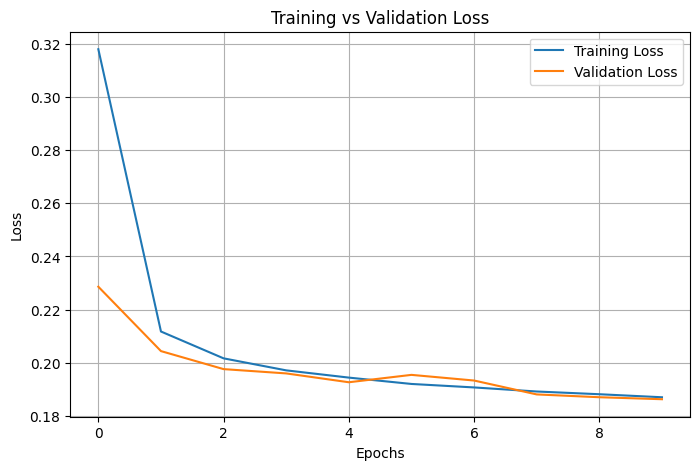

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

# Training loss
plt.plot(history.history['loss'], label='Training Loss')

# Validation loss
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

# **4. Evaluate and Visualize the Results**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


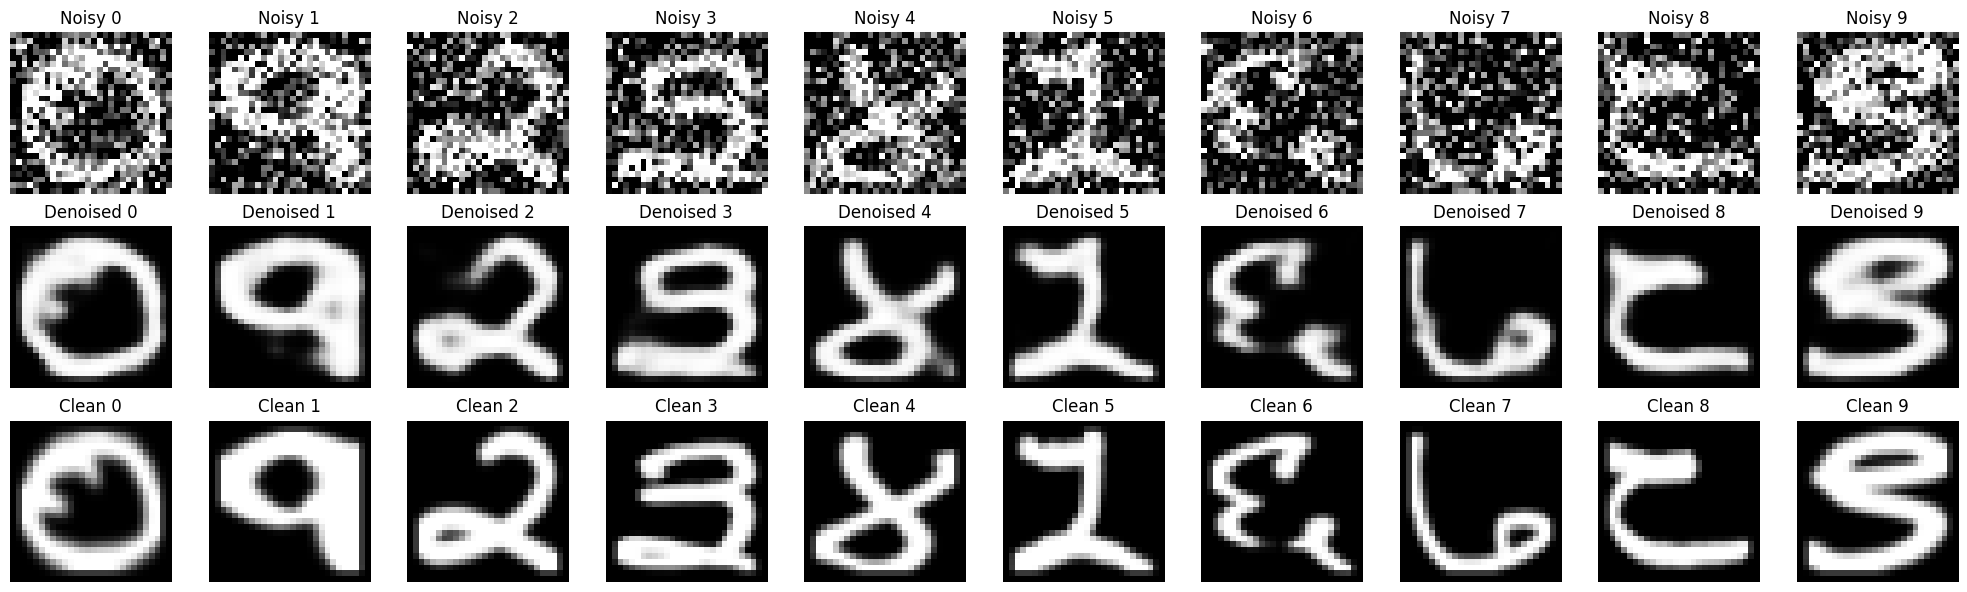

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Convert one-hot back to labels
y_test_labels = np.argmax(y_test, axis=1)

# Store one index per class
class_indices = []

for cls in range(10):
    idx = np.where(y_test_labels == cls)[0][0]  # first occurrence of each class
    class_indices.append(idx)

# Prepare selected samples
noisy_samples = x_test_noisy_high[class_indices]
denoised_samples = autoencoder.predict(noisy_samples)
clean_samples = x_test[class_indices]

# Plot
plt.figure(figsize=(20, 6))

n = 10
for i in range(n):

    # Noisy
    plt.subplot(3, n, i + 1)
    plt.imshow(noisy_samples[i].reshape(28, 28), cmap='gray')
    plt.title(f"Noisy {i}")
    plt.axis('off')

    # Denoised
    plt.subplot(3, n, i + 1 + n)
    plt.imshow(denoised_samples[i].reshape(28, 28), cmap='gray')
    plt.title(f"Denoised {i}")
    plt.axis('off')

    # Clean
    plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(clean_samples[i].reshape(28, 28), cmap='gray')
    plt.title(f"Clean {i}")
    plt.axis('off')

plt.tight_layout()
plt.show()

# **5. Experiment and Fine-Tune the Model**

**1. Noise Factor Low - 0.1**

In [ ]:
# Build the autoencoder from previous steps
autoencoder = build_autoencoder()

# Train with noisy input and clean target
history = autoencoder.fit(
  x_train_noisy_low, x_train,
  epochs=10,
  batch_size=128,
  shuffle=True,
  validation_data=(x_val_noisy_low, x_val)
  )

Epoch 1/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 55s 482ms/step - loss: 0.2646 - val_loss: 0.1748
Epoch 2/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 46s 432ms/step - loss: 0.1663 - val_loss: 0.1602
Epoch 3/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 83s 438ms/step - loss: 0.1583 - val_loss: 0.1559
Epoch 4/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 46s 432ms/step - loss: 0.1549 - val_loss: 0.1534
Epoch 5/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 48s 449ms/step - loss: 0.1530 - val_loss: 0.1516
Epoch 6/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 46s 426ms/step - loss: 0.1514 - val_loss: 0.1506
Epoch 7/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 47s 436ms/step - loss: 0.1503 - val_loss: 0.1499
Epoch 8/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 80s 416ms/step - loss: 0.1493 - val_loss: 0.1492
Epoch 9/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 46s 428ms/step - loss: 0.1487 - val_loss: 0.1479
Epoch 10/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 82s 431ms/step - loss: 0.1480 - val_loss: 0.1475


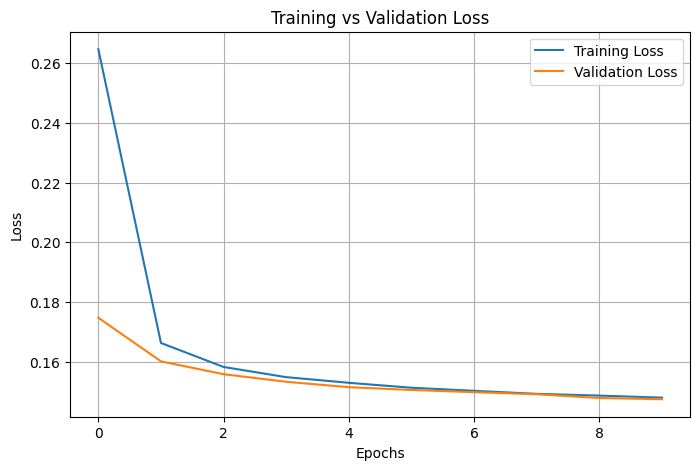

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

# Training loss
plt.plot(history.history['loss'], label='Training Loss')

# Validation loss
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step


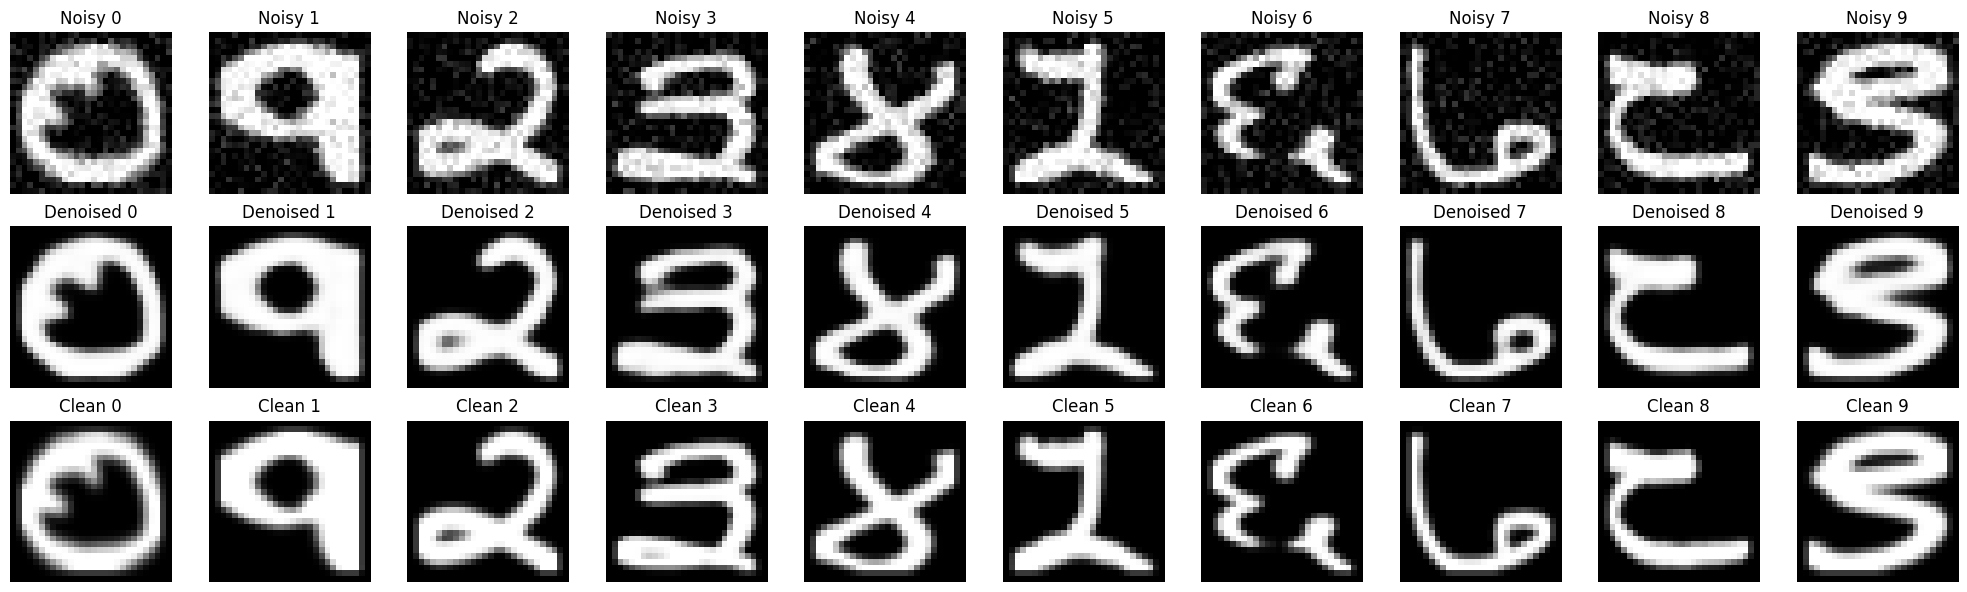

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Convert one-hot back to labels
y_test_labels = np.argmax(y_test, axis=1)

# Store one index per class
class_indices = []

for cls in range(10):
    idx = np.where(y_test_labels == cls)[0][0]  # first occurrence of each class
    class_indices.append(idx)

# Prepare selected samples
noisy_samples = x_test_noisy_low[class_indices]
denoised_samples = autoencoder.predict(noisy_samples)
clean_samples = x_test[class_indices]

# Plot
plt.figure(figsize=(20, 6))

n = 10
for i in range(n):

    # Noisy
    plt.subplot(3, n, i + 1)
    plt.imshow(noisy_samples[i].reshape(28, 28), cmap='gray')
    plt.title(f"Noisy {i}")
    plt.axis('off')

    # Denoised
    plt.subplot(3, n, i + 1 + n)
    plt.imshow(denoised_samples[i].reshape(28, 28), cmap='gray')
    plt.title(f"Denoised {i}")
    plt.axis('off')

    # Clean
    plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(clean_samples[i].reshape(28, 28), cmap='gray')
    plt.title(f"Clean {i}")
    plt.axis('off')

plt.tight_layout()
plt.show()

**Conclusion**

Higher noise level (0.5) made the reconstruction task more difficult, leading to higher loss but encouraging the model to learn more robust, structural features. Lower noise level (0.1) resulted in faster convergence and lower loss, as the input was less corrupted and easier to reconstruct. Overall, noise level directly affects the trade-off between reconstruction accuracy and feature robustness in denoising autoencoders.

**2. Architecture depth (increasing two more convolutional layers)**

In [ ]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Cropping2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

def build_encoder(input_shape=(28, 28, 1)):
  """
  Builds the encoder part of the convolutional autoencoder.
  Parameters:
  input_shape (tuple): Shape of the input image. Default is (28, 28, 1) for MNIST.
  Returns:
  input_img (Keras Input): Input layer of the model.
  encoded (Keras Tensor): Encoded representation after convolution and pooling.
  """
  input_img = Input(shape=input_shape, name="input")

  x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
  x = MaxPooling2D((2, 2), padding='same')(x)

  x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
  x = MaxPooling2D((2,2), padding='same')(x)

  x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)

  encoded = x
  return input_img, encoded

In [ ]:
def build_decoder(encoded_input):
  """
  Builds the decoder part of the convolutional autoencoder.
  Parameters:
  encoded_input (Keras Tensor): The output from the encoder.

  Returns:
  decoded (Keras Tensor): The reconstructed output after upsampling and
  convolution.
  """
  x = Conv2D(128, (3, 3), activation='relu', padding='same')(encoded_input)

  x = UpSampling2D((2, 2))(x)
  x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)

  x = UpSampling2D((2, 2))(x)
  x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)

  decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same', name="decoded")(x)
  return decoded

In [ ]:
def build_autoencoder():
  """
  Constructs and compiles the full convolutional autoencoder by connecting encoder and
  decoder.
  Returns:
  autoencoder (Keras Model): Compiled autoencoder model.
  """
  input_img, encoded_output = build_encoder()
  decoded_output = build_decoder(encoded_output)
  autoencoder = Model(inputs=input_img, outputs=decoded_output, name="autoencoder")
  autoencoder.compile(optimizer=Adam(), loss='binary_crossentropy')
  return autoencoder

In [ ]:
autoencoder = build_autoencoder()
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_62 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_63 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_64 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_65 (Conv2D)              │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_28 (UpSampling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_66 (Conv2D)              │ (None, 14, 14, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_29 (UpSampling2D) │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_67 (Conv2D)              │ (None, 28, 28, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoded (Conv2D)                │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 332,801 (1.27 MB)

 Trainable params: 332,801 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Build the autoencoder from previous steps
autoencoder = build_autoencoder()

# Train with noisy input and clean target
history = autoencoder.fit(
  x_train_noisy_high, x_train,
  epochs=10,
  batch_size=128,
  shuffle=True,
  validation_data=(x_val_noisy_high, x_val)
  )

Epoch 1/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 160s 1s/step - loss: 0.3021 - val_loss: 0.2242
Epoch 2/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - loss: 0.2034 - val_loss: 0.1944
Epoch 3/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - loss: 0.1915 - val_loss: 0.1915
Epoch 4/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 160s 1s/step - loss: 0.1864 - val_loss: 0.1861
Epoch 5/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - loss: 0.1837 - val_loss: 0.1884
Epoch 6/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - loss: 0.1816 - val_loss: 0.1805
Epoch 7/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - loss: 0.1801 - val_loss: 0.1802
Epoch 8/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 147s 1s/step - loss: 0.1786 - val_loss: 0.1783
Epoch 9/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - loss: 0.1774 - val_loss: 0.1773
Epoch 10/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - loss: 0.1761 - val_loss: 0.1769


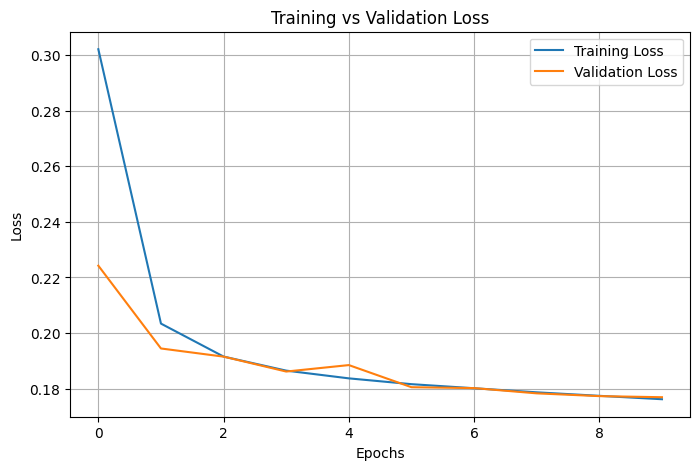

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

# Training loss
plt.plot(history.history['loss'], label='Training Loss')

# Validation loss
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step


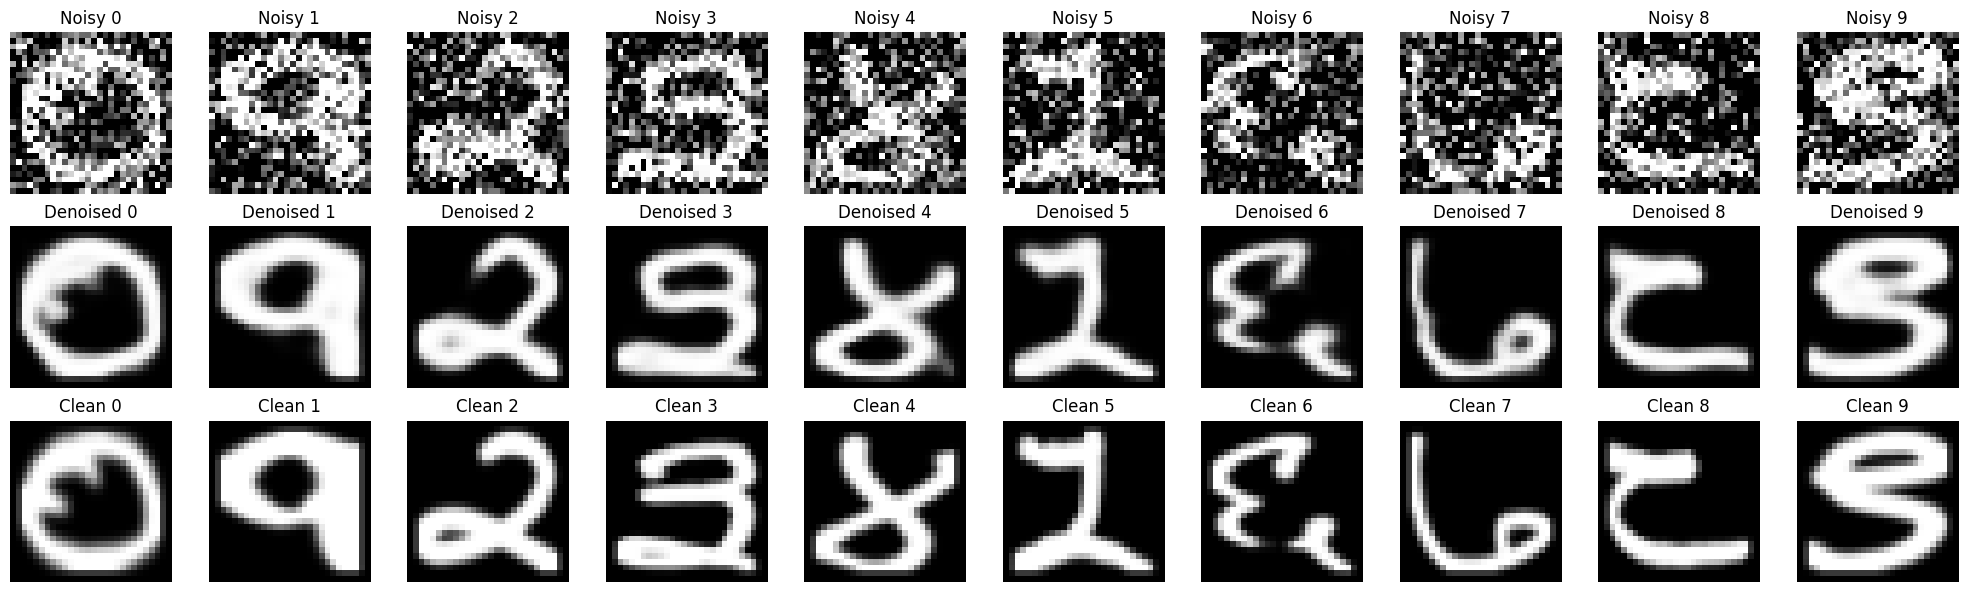

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Convert one-hot back to labels
y_test_labels = np.argmax(y_test, axis=1)

# Store one index per class
class_indices = []

for cls in range(10):
    idx = np.where(y_test_labels == cls)[0][0]  # first occurrence of each class
    class_indices.append(idx)

# Prepare selected samples
noisy_samples = x_test_noisy_high[class_indices]
denoised_samples = autoencoder.predict(noisy_samples)
clean_samples = x_test[class_indices]

# Plot
plt.figure(figsize=(20, 6))

n = 10
for i in range(n):

    # Noisy
    plt.subplot(3, n, i + 1)
    plt.imshow(noisy_samples[i].reshape(28, 28), cmap='gray')
    plt.title(f"Noisy {i}")
    plt.axis('off')

    # Denoised
    plt.subplot(3, n, i + 1 + n)
    plt.imshow(denoised_samples[i].reshape(28, 28), cmap='gray')
    plt.title(f"Denoised {i}")
    plt.axis('off')

    # Clean
    plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(clean_samples[i].reshape(28, 28), cmap='gray')
    plt.title(f"Clean {i}")
    plt.axis('off')

plt.tight_layout()
plt.show()

**Conclusion**

The 6-layer autoencoder (32→64→128) outperforms the 4-layer version by achieving lower reconstruction loss and better convergence, demonstrating that increasing model depth improves feature learning and reconstruction quality. However, this improvement comes at the cost of higher computational time, indicating a trade-off between accuracy and efficiency.